# Fishing for PACE Data in Polygons and Points

## Wrangling shape files + satellite matchups

This tutorial is two-fold, but both represent scenarios you are likely to encounter if you are dealing with fisheries science + satellite data. 

In the fisheries world, we often don't care about **every pixel in the ocean.** Sometimes we just want to know what's happening inside a specific fishing boundary, habitat, or management area. Maybe it's a closed bay, a reef tract, or an aquaculture farm. Regardless, at some point in time, you are likely to encounter shape files. Python (geopandas, specifically) handles these with ease, but there are some nuances when shapefiles try to talk to satellite data files. 

Within these boundaries, we also may be sitting on a treasure trove of very useful survey or telemetry data, provding information about fish species and catch, plankton tows, animal tag points, underwater images, acoustics, CTD data, what have you... Can PACE can help inform how these critters interact with the aquatic environment? Maybe, but first we need to match up our data. It's relatively simple to extract a point from a satellite image, but going through multiple points and time stamps can be a major time-suck. So, let's set up a workflow to help us along. We're going to get some help from our friends at the [Southeast Area Monitoring & Assessment Program](https://seamapdata.gsmfc.org/), or SEAMAP. There is a lot of really cool fisheries data pertaining to the U.S. Gulf Coast in here (species, size, abundance, environmental parameters, and more), but for today's exercise we're going to keep it simple and grab a more generic bulk abundance data. 

By the end of this tutorial, you will have 

1. Imported, explored, and displayed a shape file for Large Marine Ecosystems
2. Clipped PACE data to the shape of a polygon
3. Imported data from SEAMAP campaigns and shown the locations on a satellite image
4. Extracted PACE reflectance data at the corresponding dates/locations
5. Performed a rudimentary prediciton model of fish abundance from the data

## *Are you ready?*

## Let’s dive in! 🐠


## The shape of my heart... and LMEs

I grabbed the following shape file from https://github.com/datasets/lme-large-marine-ecosystems. An LME, or Large Marine Ecosystem, is a large ocean region defined by ecological criteria like bathymetry, hydrography, and productivity, with boundaries extending from river basins to the continental shelf. There are 66 defined LMEs globally, and the concept is used for ecosystem-based management to promote international cooperation on issues like sustainable fishing, pollution reduction, and climate change adaptation across these shared marine areas. First, let's open it and see what [Coordinate Reference System (CRS)](https://en.wikipedia.org/wiki/Spatial_reference_system) it is using. 

In [11]:
import geopandas as gpd

gdf = gpd.read_file('lme66.shp')

# The Coordinate Reference System (CRS) is stored in the .crs attribute
current_crs = gdf.crs
print(f"\n🗺️ The shapefile's Coordinate Reference System (CRS) is:")
print(current_crs)


🗺️ The shapefile's Coordinate Reference System (CRS) is:
EPSG:4326


Whew. Good thing. This is the same reference system used for most satellite files (WGS84), so they should play nicely. But, if you run into a file that has another projection, the code below will get you aligned. 

In [12]:
# In this case the CRS is EPSG:4326, which is a common standard for satellite data. 
# If this is NOT the case, you can convert the coordinate system:

gdf_wgs84 = gdf.to_crs("EPSG:4326")
gdf_wgs84

,OBJECTID,LME_NUMBER,LME_NAME,Shape_Leng,Shape_Area,geometry
0,1,23.0,Baltic Sea,219.326402,61.950021,"POLYGON ((10.97944 54.38055, 10.98611 54.37805..."
1,2,52.0,Sea of Okhotsk,145.932989,213.796584,"POLYGON ((156.70705 51.18858, 156.62592 51.160..."
2,3,22.0,North Sea,209.486403,103.965247,"POLYGON ((5.27889 61.98027, 5.24917 61.97388, ..."
3,4,2.0,Gulf of Alaska,468.695688,203.793868,"POLYGON ((-124.59823 47.90313, -125.85582 47.0..."
4,5,9.0,Labrador - Newfoundland,270.847479,114.597691,"MULTIPOLYGON (((-64.56793 60.45509, -60.09442 ..."
...,...,...,...,...,...,...
61,62,63.0,Hudson Bay Complex,391.717406,209.464313,"MULTIPOLYGON (((-64.79667 59.98027, -64.81194 ..."
62,63,55.0,Beaufort Sea,478.747080,292.450949,"POLYGON ((-122.68333 76.0198, -122.6989 76.018..."
63,64,66.0,Canadian High Arctic - North Greenland,1059.501342,297.732265,"MULTIPOLYGON (((-122.5625 76.01443, -122.56585..."
64,65,64.0,Central Arctic,760.568294,3181.188855,"POLYGON ((180 75.98248, 179.29807 75.97633, 17..."


## Examining the polygons 

Let's see where all these polygons are!

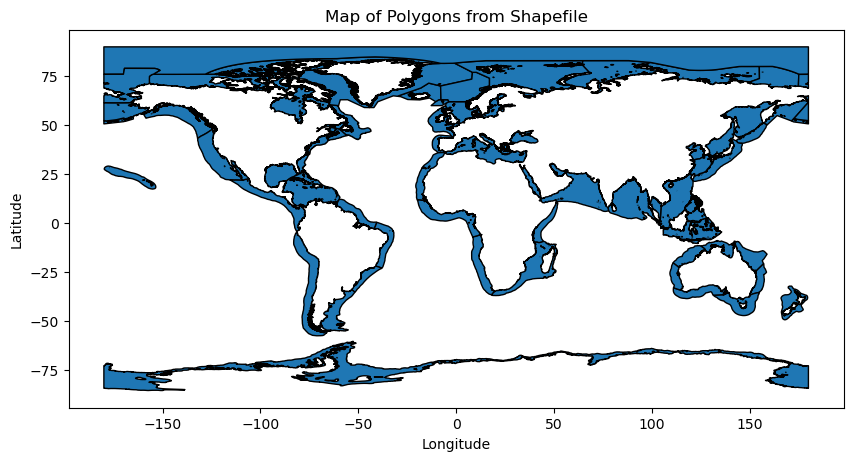

In [13]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(edgecolor='black', figsize=(10, 10))
plt.title("Map of Polygons from Shapefile")
plt.xlabel("Longitude") 
plt.ylabel("Latitude") 
plt.show()

## Getiing more specific

We can see the names of the column headers when we initially examined the contents of the file. However, it was truncated. Let's print out the entire list so we can see what LMEs are all contained within

In [14]:
import pandas as pd

# Select relevant columns
lme_reference_df = gdf[['LME_NUMBER', 'LME_NAME']]

# Sort the table by the LME_NUMBER (from 1.0 to 66.0)
lme_reference_df = lme_reference_df.sort_values(by='LME_NUMBER').reset_index(drop=True)

# Use pd.option_context to temporarily ensure all 66 rows are displayed
with pd.option_context('display.max_rows', 70):
    print("Full List of LMEs (Sorted by LME_NUMBER):")
    print(lme_reference_df)

Full List of LMEs (Sorted by LME_NUMBER):
    LME_NUMBER                                  LME_NAME
0          1.0                           East Bering Sea
1          2.0                            Gulf of Alaska
2          3.0                        California Current
3          4.0                        Gulf of California
4          5.0                            Gulf of Mexico
5          6.0          Southeast U.S. Continental Shelf
6          7.0          Northeast U.S. Continental Shelf
7          8.0                             Scotian Shelf
8          9.0                   Labrador - Newfoundland
9         10.0                  Insular Pacific-Hawaiian
10        11.0          Pacific Central-American Coastal
11        12.0                             Caribbean Sea
12        13.0                          Humboldt Current
13        14.0                          Patagonian Shelf
14        15.0                        South Brazil Shelf
15        16.0                         East Br

# Let's just grab a few

You can arrange the code to ingest the LME_NUMBER, if you like, but here we opted to use the full LME_NAME.

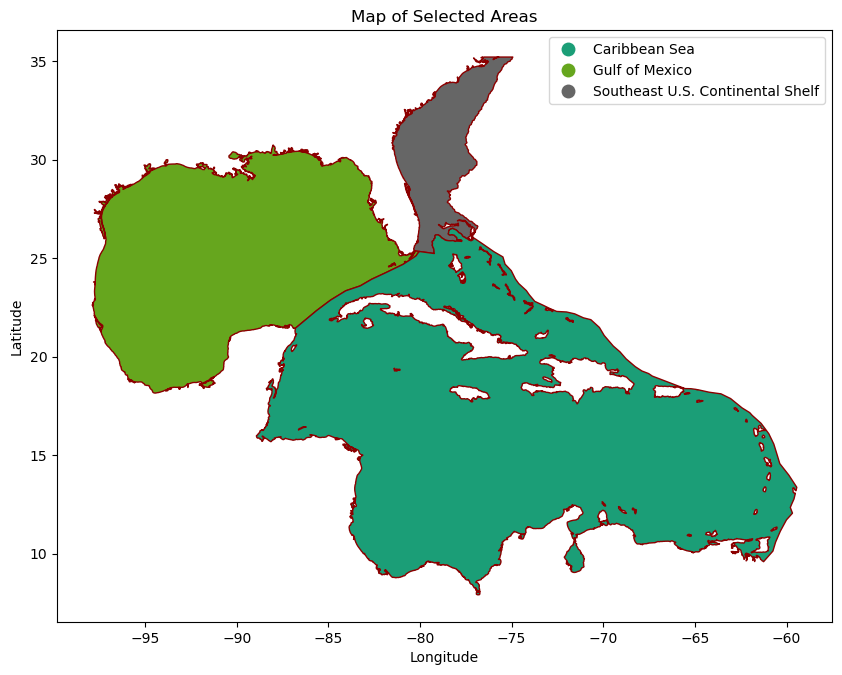

In [15]:
import matplotlib.pyplot as plt

# Define the specific LME names you want to plot
selected_names = ['Southeast U.S. Continental Shelf', 'Gulf of Mexico', 'Caribbean Sea']

# Filter the GeoDataFrame using .isin()
selection_gdf_names = gdf[gdf['LME_NAME'].isin(selected_names)]

# Plot the filtered GeoDataFrame
selection_gdf_names.plot(
    column='LME_NAME', # Use the name column for distinct coloring
    legend=True,
    cmap='Dark2',
    edgecolor='darkred',
    linewidth=1.0,
    figsize=(10, 10)
)

plt.title("Map of Selected Areas")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Boundaries can be as large as major Ecosystems, or as small as 

## Enough shaping around! Let's get some PACE data!

In some cases, it might be usedful to extract satellite data only from within a certain boundary (e.g., a Marine Protected Area). In this case, it may be useful to clip your satellite data down to the size of your shapefile so you're not lugging around a global Level-3 file for your analyses. First, let's grab our data. 

Since we're going to extract remote sensing reflectance later, we'll grab the Apparent Visible Wavelength (AVW) product as a general represenation of spectral tendency. 

In [16]:
import earthaccess
import xarray as xr
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_AVW",
    temporal = ("2024-01-01", "2024-12-31"),
    granule_name="*.SNSU.*.4km.*"
)
fileset = earthaccess.open(results);

# Load relevant datasets
dataset = xr.open_dataset(fileset[0])
latitude = dataset["lat"]
longitude = dataset["lon"]
AVW = dataset["avw"]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

## Rio!!

Over the course of these tutorials, we've been largely dealing with xarray when dealing with satellite data. However, xarray alone does not understand geospatial boundaries. xarray is great for labeled N-dimensional arrays, but it has no built-in understanding of coordinate reference systems (CRS), spatial dimensions (lat/lon), geospatial polygon clipping, or reprojection. In other words, you are going to struggle to get your shapefile to cooperate with you because they are generally made with GIS applications in mind. If you try to clip or mask using only xarray, you have to manually build a mask array at the grid resolution, which is slow, verbose, and error-prone. 

Below, rio.clip() performs polygon masking correctly and efficiently. Funny little nuance though, since rioxarray is built on top of rasterio (a GIS-friendly python library), it follows classic GIS conventions where x = horizontal coordinates (i.e., longitude), and y = vertical coordiantes (i.e., latitude). Yeah, we have to tell it that explicitly, and then go back and re-define the coordinate reference system for your satellite image, but this is the way (*this is the way*).

Alright, pick an LME of your preference and specify below:

In [17]:
import rioxarray # For clipping satellite data

# Select your LME of choice from the list we generated earlier
lme_name = 'Gulf of Mexico'
LME = gdf[gdf['LME_NAME'] == lme_name]

# rioxarray requires coordinates to be set as dimensions
AVW_xy = AVW.rename({"lon": "x", "lat": "y"})
AVW_xy = AVW_xy.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

# Assign the CRS (PACE L3 data is WGS 84, which is EPSG:4326)
AVW_xy = AVW_xy.rio.write_crs("EPSG:4326")

# Reprojected LME polygon to match AVW data CRS
# We already know that the CRS matches, but this is useful tidbit if it doesn't
LME_4326 = LME.to_crs(AVW_xy.rio.crs)

# Clip the AVW data to the LME boundary
AVW_clipped = AVW_xy.rio.clip(
    LME_4326.geometry.values,
    LME_4326.crs
)

## Let's check it out!

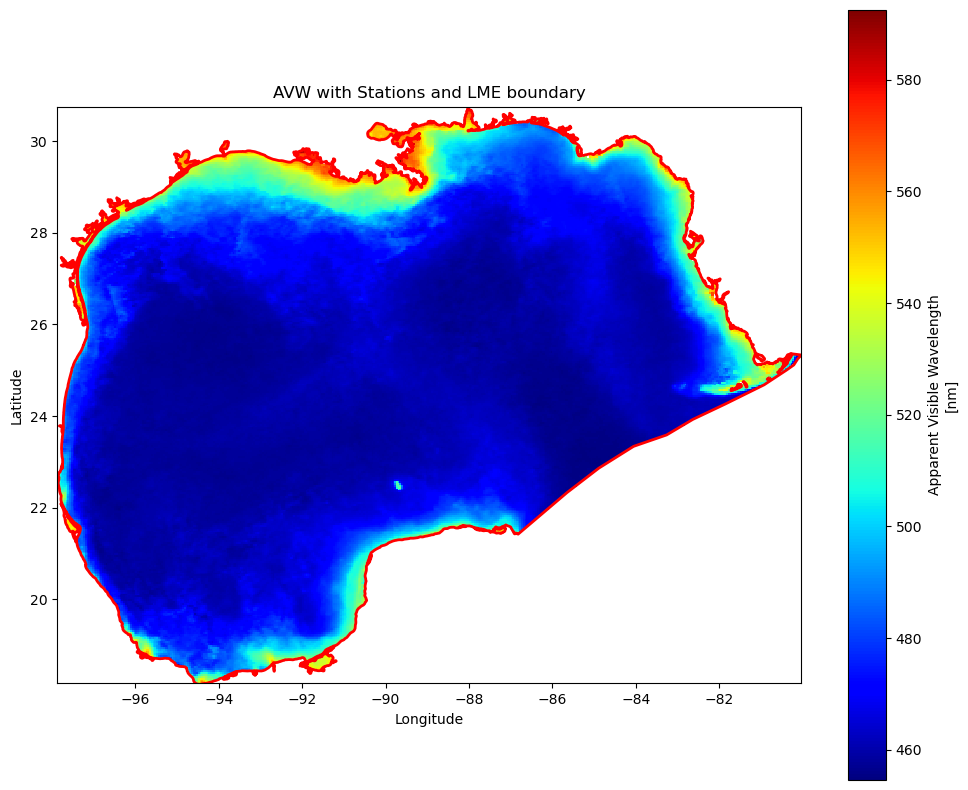

In [62]:
fig, ax = plt.subplots(figsize=(12,10))
AVW_clipped.plot(ax=ax, cmap='jet', add_colorbar=True)
LME_4326.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)

plt.title("AVW with LME boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

If this were a smaller geographic shapefile (for example, a marine sanctuary), you could use it to compute the mean over the entire area or to construct a time series. We cover time-series analysis in the Kd tutorial, so we won’t repeat it here. For now, the key takeaway is that you can isolate satellite data within irregular, polygon-defined boundaries, rather than relying on a simple rectangular bounding box. 

Next, we’ll shift focus and extract satellite data at individual point locations, sampling single pixels across multiple time steps and spatial domains.

## PACE and Fishies

As mentioned at the start of this tutorial, we’ll now pivot to working with ship-based NOAA Fisheries survey data from SEAMAP (2024–present). Specifically, we’re going to extract PACE remote-sensing reflectance (Rrs) at each survey station, allowing us to sample satellite data at discrete point locations rather than over spatial polygons.

To keep things straightforward, we’ll start by importing a clean .csv file containing latitude, longitude, sampling date, as well as several in situ variables collected on the surveys, including temperature, salinity, oxygen, chlorophyll (fluorometry), turbidity, Secchi depth, and more. In addition, we want some form of fisheries data, so we also extracted the variable 'TOT_LIVE', which represents the combined wet weight (kg) of all fish, crustaceans, and other organisms caught. Is this the most meaningful fisheries metric available? Probably not, but it works well for illustrating the workflow, which is our main focus here. The SEAMAP dataset has plenty more to explore including species abundances and size information. 

If you’d like to follow along with your own data, any .csv containing Latitude, Longitude, and Loc_date (formatted as MM/DD/YYYY) should work seamlessly with the code below.

For this next step, we no longer need the spatially clipped datasets, so we’ll return to our old friend xarray. The first order of business is to load the .csv file and identify all unique sampling dates. This is important because we’ll be retrieving data from NASA Earthdata, and it’s far more efficient to request each date only once rather than repeatedly downloading the same files.

In [42]:
# === Load telemetry data ===
track_df = pd.read_csv("plankton_summary_2024_present.csv")
track_df["Loc_date"] = pd.to_datetime(track_df["Loc_date"])

unique_dates = track_df["Loc_date"].sort_values().unique()
print(f"Number of unique dates to extract: {len(unique_dates)}")

Number of unique dates to extract: 61


## Map it out

Let's take a look at where all these stations are, and plot them on our already clipped satellite map. 

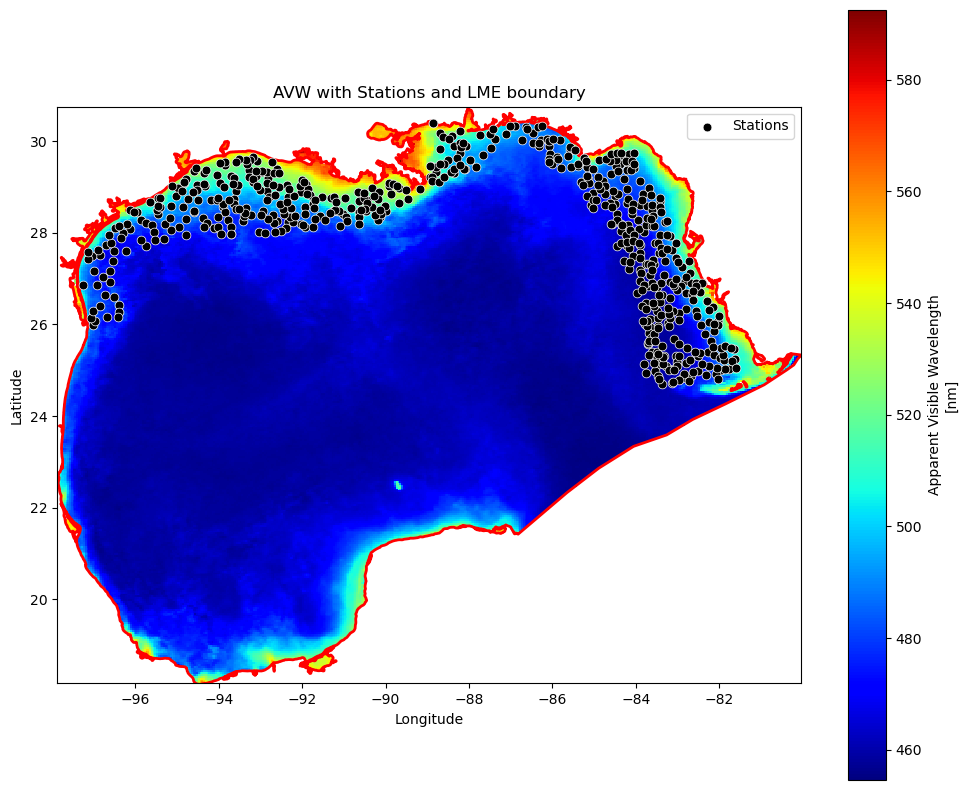

In [63]:
fig, ax = plt.subplots(figsize=(12,10))
AVW_clipped.plot(ax=ax, cmap='jet', add_colorbar=True)
LME_4326.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)

# Add scatter points
ax.scatter(
    track_df["Longitude"], track_df["Latitude"],
    s=40,
    c='black',
    edgecolor='white',
    linewidth=0.5,
    label="Stations"
)

ax.legend(loc="upper right")
plt.title("AVW with Stations and LME boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Decisions, decisions...

You have a bit of an existential decision to make here. At what temporal resolution will you extract your data? It will depend on your application, on your project goals, and the characteristics of your data. Trying to characterize general fish habitat preferences for highly migratory species? You can probably grab the closest 8-day average and make the assumption that most mesoscale features they interact with are coherent at weekly time scales. Looking at plankton tow information or counting fish species that are heavily reliant on tidal cycles? That data is likely a little more tied to the time/space it was collected, and you would want to look at daily values. The tradoff is that cloud cover is going to significantly chop down your data, and the weekly averages will help you get a lot more data back for model development. As an example, I ran the code below using 8-day versus 1-day composites, and I went from 532 valid matchups to 184 matchups. If your model development can tolerate some random error, you may opt to use the longer composites. 

## Anyway...

Back to the script. For every unique date found in the .csv, we're going to query NASA for that corresponding daily Level 3 file. Then, for that file, we're going to loop through all the points within that day and compute a 3x3 mean of the remote sesning reflectance spectrum. We're going to collect this info in a 'dictionary' and then append the data to our .csv in one swoop at the end. This will take a few minutes. There may be more efficient ways of doing this, but this approach avoids the pitfall of stacking up memory and crashing your kernel. For one, we're streaming via earthaccess.open(), which returns EarthAccessFile objects that stream the data on-demand. Only the chunks of data you actually access with xarray (ds["Rrs"].isel(...)) are read into memory. Secondly, using "with" statements ensures that datasets are closed immediately after processing. Once the block ends, memory used by ds is released, and we avoid keeping multiple files open at the same time. Finally, we're really only loading in 3x3 pixel boxes at a time using the "slice" function. This avoids reading the full dataset into memory. 

It doesn't take but a few minutes, but now is a good time for a beverage break. 

In [ ]:
import earthaccess
import xarray as xr
import pandas as pd
import numpy as np
from tqdm import tqdm
import re

# Login
auth = earthaccess.login()

# Provide product parameters
short_name = "PACE_OCI_L3M_RRS"
granule_name = "*.DAY.*.4km.*"

results_list = []

# Loop through unique dates
# tqdm is going to give us a progress bar. Not necessary, but nice
for date in tqdm(unique_dates, desc="Processing unique dates"):

    start = end = date.strftime("%Y-%m-%d")

    # Search & open files for exact date
    results = earthaccess.search_data(
        short_name=short_name,
        temporal=(start, end),
        granule_name=granule_name
    )

    if not results:
        continue

    fileset = earthaccess.open(results)

    for ea_file in fileset:  # iterate EarthAccessFile objects
        with xr.open_dataset(ea_file, engine="h5netcdf") as ds:

            lat_vals = ds.lat.values
            lon_vals = ds.lon.values

            # Extract 3x3 pixel boxes for each point
            points_today = track_df[track_df["Loc_date"] == date]
            for idx, row in tqdm(points_today.iterrows(), total=len(points_today), desc="Points in granule", leave=False):
                lat_center, lon_center = row["Latitude"], row["Longitude"]
                lat_idx = np.abs(lat_vals - lat_center).argmin()
                lon_idx = np.abs(lon_vals - lon_center).argmin()
                lat_slice = slice(max(lat_idx-1,0), min(lat_idx+2, len(lat_vals)))
                lon_slice = slice(max(lon_idx-1,0), min(lon_idx+2, len(lon_vals)))
                box = ds["Rrs"].isel(lat=lat_slice, lon=lon_slice)

                # Mean Rrs over full wavelength
                rrs_mean = box.mean(dim=["lat","lon"], skipna=True).compute()

                # Compute AVW manually (400-700 nm), you can change the wavelength range below if desired
                rrs_subset = box.sel(wavelength=slice(400,700)).mean(dim=["lat","lon"], skipna=True).compute()
                AVW_val = rrs_subset.sum(dim="wavelength") / (rrs_subset / rrs_subset.wavelength).sum(dim="wavelength")

                # Prepare row dict
                result_row = {'Original_Index': idx, **row.to_dict(), "AVW": AVW_val.item()}
                for wl in rrs_mean.wavelength.values:
                    result_row[f"Rrs_{int(wl)}"] = rrs_mean.sel(wavelength=wl).item()

                results_list.append(result_row)

# Combine results & save
if results_list:
    final_df = pd.DataFrame(results_list).set_index("Original_Index").sort_index()
    output_file = "plankton_summary_2024_present_PACE_RRS_1D_3x3.csv"
    final_df.to_csv(output_file)
    print(f"CSV saved: {output_file}")
else:
    print("No data extracted. Check date ranges and data availability.")

## Let's explore a bit

For every data point that we read in which had a lat/lon/date, we now have a corresponding Rrs spectrum (or whatever PACE products you chose to pull). For something as complex and nuanced as habitat modeling, we're not likely to see a tight correlation between Rrs and total fish catch ("TOT_LIVE"), but it's a good exercise to explore the relative significance of including PACE data. Before we do anything with this data, let's just see what the average shape of Rrs looks like at various fish biomass levels. First, let's open up that spreadsheet we just created:

In [1]:
import numpy as np
import pandas as pd

df2 = pd.read_csv("plankton_summary_2024_present_PACE_RRS_1D_3x3.csv")
tot_live = df2["TOT_LIVE"].replace(0, np.nan)  # avoid log(0)
rrs_cols = [c for c in df2.columns if c.startswith("Rrs_")]
wavelengths = np.array([int(c.split("_")[1]) for c in rrs_cols])

print(f"Min value in TOT_LIVE: {np.min(tot_live)}")
print(f"Max value in TOT_LIVE: {np.max(tot_live)}")

Min value in TOT_LIVE: 0.2
Max value in TOT_LIVE: 456.7


Since we're dealing with living things, and the biomass data extends across 3 orders of magnitude, let's go ahead and log-transform the biomass data so that it normalizes the distribution a bit. Below, what this allows us to do is define a custom number of equally spaced bins (in log10 space), in which we can take the mean of all Rrs spectra within each bin, and plot it out. This is qualitative exploration at this point, but it feeds into our devious plot to demystify spectral reflectance data and get a general sense of patterns.


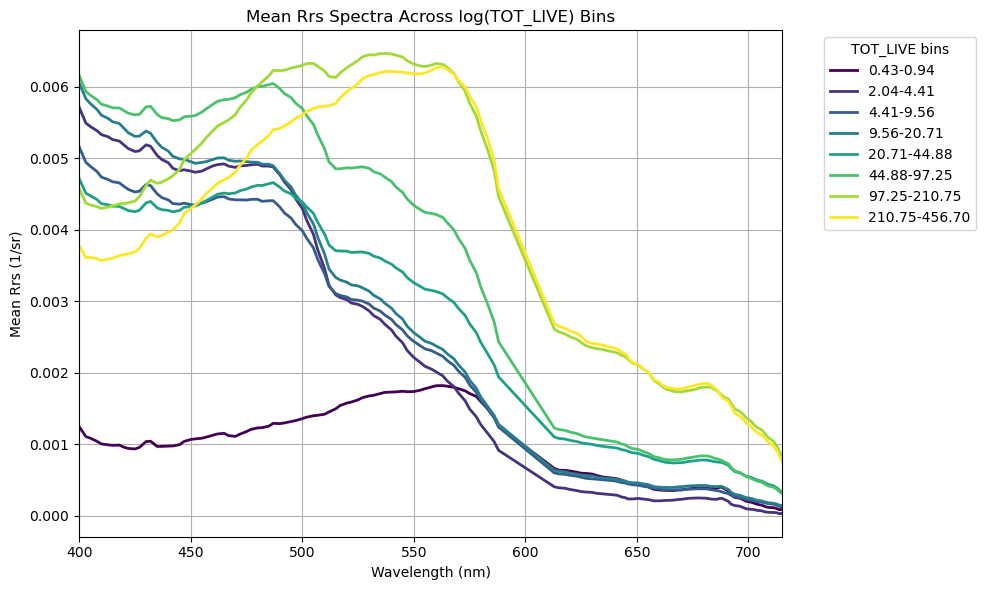

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df2 = pd.read_csv("plankton_summary_2024_present_PACE_RRS_1D_3x3.csv")
tot_live = df2["TOT_LIVE"].replace(0, np.nan)  # avoid log(0)
rrs_cols = [c for c in df2.columns if c.startswith("Rrs_")]
wavelengths = np.array([int(c.split("_")[1]) for c in rrs_cols])

# Define log-space bins
safe_tot = tot_live.clip(lower=1e-6) #this avoids issues with zeros
num_bins = 10
bins_log = np.logspace(np.log10(safe_tot.min()), np.log10(safe_tot.max()), num_bins + 1)
df2["bin_log"] = pd.cut(safe_tot, bins_log, include_lowest=True)

# Compute mean spectra per bin
mean_spectra = df2.groupby("bin_log", observed=True)[rrs_cols].mean().dropna(how="all")

# Plot
cmap = plt.colormaps.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(mean_spectra)))
plt.figure(figsize=(10,6))

for (bin_interval, row), color in zip(mean_spectra.iterrows(), colors):
    label = f"{bin_interval.left:.2f}-{bin_interval.right:.2f}"
    plt.plot(wavelengths, row.values, color=color, linewidth=2, label=label)

plt.xlabel("Wavelength (nm)")
plt.xlim(400, 715)
plt.ylabel("Mean Rrs (1/sr)")
plt.title("Mean Rrs Spectra Across log(TOT_LIVE) Bins")
plt.legend(title="TOT_LIVE bins", bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

## Yay! More squiggly lines!

Generally speaking, catch biomass increases in greener, phytoplankton-dominated waters and decreases in bluer waters (no big surprise). Interestingly, we find an exception to this trend in the lowest biomass bin (0.43 - 0.94 kg) - this contains average green-shifted reflectance spectra, but the total magnitude of reflectance is significantly lower than the others. What's the deal? As we discussed in the Rrs tutorial, the low magnitude likely suggests the presence of highly absorbing materials... CDOM plume perhaps? High CDOM levels tends to be a result of allochthonous inputs, i.e., river runoff. If this is the case, we're likely to see lower salinity in these waters as well. That still doesn't explain the low biomass though. Just for funzies, let's take a look at some of those other environmental parameters collected using the same biomass bin parameters. We'll pull surface temperature, surface salinity, bottom salinity, and bottom oxygen. 

In [21]:
# Compute mean salinity + oxygen per bin
mean_vals = df2.groupby("bin_log", observed=True)[["TEMPSURF", "SALSURF", "SALMAX", "OXYMAX"]].mean()

# Print each bin with both means
for bin_interval, row in mean_vals.iterrows():
    print(
        f"bin interval  {bin_interval.left:.2e} - {bin_interval.right:.2e}: "
        f"mean TEMPSURF = {row['TEMPSURF']:.2f}, "
        f"mean SALSURF = {row['SALSURF']:.2f}, "
        f"mean SALBTM = {row['SALMAX']:.2f}, "
        f"mean OXYBTM = {row['OXYMAX']:.2f}"
    )


bin interval  1.99e-01 - 4.33e-01: mean TEMPSURF = 31.18, mean SALSURF = 26.72, mean SALBTM = 35.81, mean OXYBTM = 0.20
bin interval  4.33e-01 - 9.39e-01: mean TEMPSURF = 30.51, mean SALSURF = 24.22, mean SALBTM = 32.94, mean OXYBTM = 0.83
bin interval  9.39e-01 - 2.04e+00: mean TEMPSURF = 30.29, mean SALSURF = 33.34, mean SALBTM = 36.48, mean OXYBTM = 6.30
bin interval  2.04e+00 - 4.41e+00: mean TEMPSURF = 29.04, mean SALSURF = 34.51, mean SALBTM = 36.14, mean OXYBTM = 5.80
bin interval  4.41e+00 - 9.56e+00: mean TEMPSURF = 28.10, mean SALSURF = 34.16, mean SALBTM = 35.87, mean OXYBTM = 5.43
bin interval  9.56e+00 - 2.07e+01: mean TEMPSURF = 29.07, mean SALSURF = 33.90, mean SALBTM = 36.32, mean OXYBTM = 5.50
bin interval  2.07e+01 - 4.49e+01: mean TEMPSURF = 28.68, mean SALSURF = 33.79, mean SALBTM = 36.32, mean OXYBTM = 5.54
bin interval  4.49e+01 - 9.73e+01: mean TEMPSURF = 28.25, mean SALSURF = 34.16, mean SALBTM = 35.51, mean OXYBTM = 5.67
bin interval  9.73e+01 - 2.11e+02: mean 

## Holy Hypoxia!

Yessiree Bob. $\Delta$Salinity between surface and bottom implies a freshwater lense has stratified the water column. With (presumably) high nutrients, low benthic light (no photosynthesis), and trapped bottom waters, we see the system has become hypoxic/borderline anoxic owing to the cumulative effect of microbial respiration in waters that are not being ventilated to the surface. Classic "Dead Zone". No wonder there are no fishies there! Anyhow, we're getting away from our main point, but just by looking at the reflectance data patterns, we were able to initially that environmental parameters are a bit different here. Now back to our programming. 

## Let's make a heatmap y'all!

What? It's exciting. We have a lot of spectral data, what else can we tease out here? Again, we're not expecting any sort of robust relationship here, but let's keep using TOT_LIVE, and see if there are additional inferences that emerge between hyperspectral PACE reflectances and fish catch. First, let's pull out all that new data we got running the matchup script.

In [22]:
import pandas as pd
import numpy as np

# Load data
CSV_FILE = "plankton_summary_2024_present_PACE_RRS_1D_3x3.csv"
df = pd.read_csv(CSV_FILE)

# Extract Rrs bands + wavelengths between 400–700 nm 
rrs_cols = [c for c in df.columns if c.startswith("Rrs_") and 400 <= float(c.split("_")[1]) <= 700]
rrs_cols = sorted(rrs_cols, key=lambda c: float(c.split("_")[1]))
wavelengths = np.array([float(c.split("_")[1]) for c in rrs_cols])

# Clipping outliers and zeros to avoid division errors
rrs = df[rrs_cols].clip(lower=0.000001, upper=0.5)
rrs.columns = wavelengths  # ensure numeric labels

After taking a look at the mean hyperspectral Rrs across the different biomass catch bins, we want to dig a little deeper and be more quantitative. To do that, we’re going to play with a simple two-band algorithm approach, where we combine pairs of spectral bands using basic math. Focusing on two bands allows us to make a really useful plot that showcases the utility of hyperspectral data: a pairwise correlation matrix. This provides basic information on narrowband features that may be related to our given parameter of interest. We're not ignoring the hyperspetral data, we're actually leveraging it to optimize the best answer.

For this round, we’ll use a normalized difference index (NDI), mostly because it’s simple and kind of fun:

$NDI = ({\lambda}_{1} - {\lambda}_{2}) / ({\lambda}_{1} + {\lambda}_{2})$

There’s no particular scientific reason we have to use NDI here. For a pairwise correlation matrix, you could just as easily use any two-band mathematical combination, e.g. ratios, subtractions, exponents, etc. NDI is just a convenient, well-behaved choice to start with.

Using the hyperspectral bands we have, we’ll compute every possible two-band NDI combination. Then, for each band pair, we’ll look at how well that NDI correlates with our parameter of interest (in this case, TOT_LIVE). Plotting those correlation coefficients as a heatmap gives us a quick way to see which band combinations look most promising.

With over 100 bands at our disposal, the hyperspectral capability of PACE really opens things up, letting us test band combinations that simply haven’t been explored before. Fair warning: running all those combinations might take a minute.

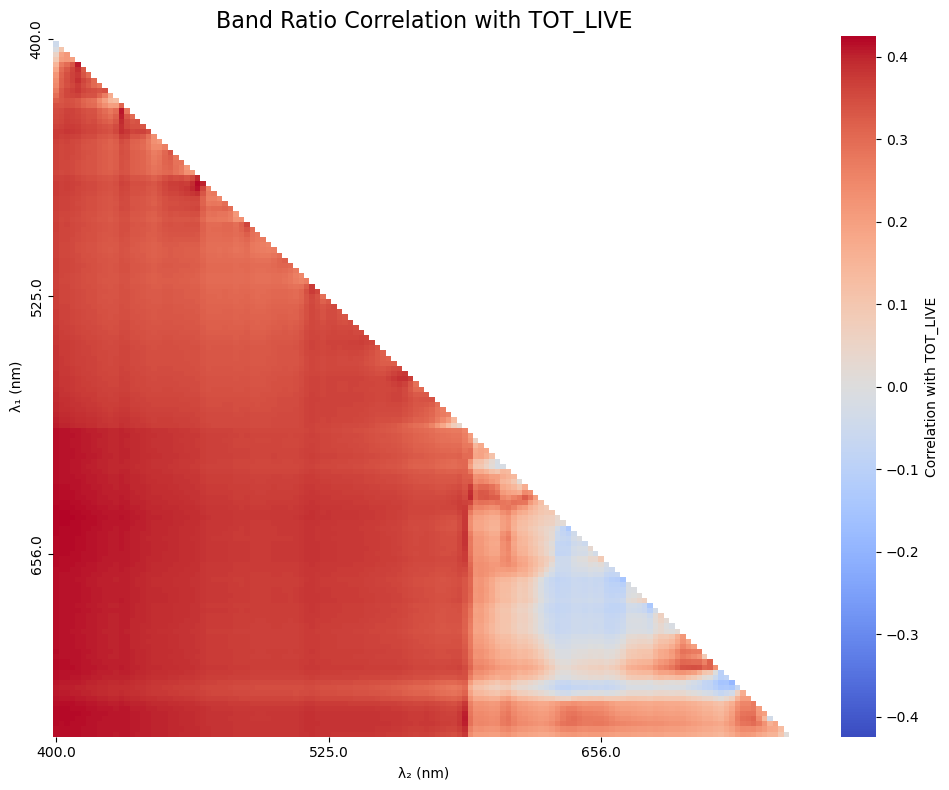

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify target variable
param = "TOT_LIVE"
target = np.log10(df[param].clip(lower=1e-4))

# Set up NDI correlation matrix
ndi_corr = pd.DataFrame(index=wavelengths, columns=wavelengths, dtype=float)

# Loop NDI calculation + correlation with target
for wl1 in wavelengths:
    for wl2 in wavelengths:
        if wl1 == wl2:
            continue
        #ratio = (rrs[wl1]) / (rrs[wl2])
        ndi = (rrs[wl1] - rrs[wl2]) / (rrs[wl1] + rrs[wl2])
        ndi_corr.at[wl1, wl2] = ndi.corr(target)

# Plot
mask = np.triu(np.ones_like(ndi_corr, dtype=bool))
cmax = max(0.1, np.nanmax(np.abs(ndi_corr.values)))

plt.figure(figsize=(10, 8))
sns.heatmap(
    ndi_corr, cmap="coolwarm", center=0,
    mask=mask | ndi_corr.isna().values,
    vmin=-cmax, vmax=cmax,
    xticklabels=50, yticklabels=50,
    cbar_kws={"label": f"Correlation with {param}"}
)
plt.title(f"Band Ratio Correlation with {param}", fontsize=16)
plt.xlabel("λ₂ (nm)")
plt.ylabel("λ₁ (nm)")
plt.tight_layout()
plt.show()

Cool, cool. We're kind of eye-balling it at this point, so let's sort out what the 5 best combos were. It is likely that the first 5 combinations will be very close to one another due to cross-correlation of the nearby color bands, so you are welcome to put out a hundred values if you'd like (it'll just be a ltitle messy).

In [33]:
# How many correlations do you want to see?
order_index = 5

# Flatten the correlation matrix and drop NaNs
ndi_flat = ndi_corr.stack().dropna()

# Sort by absolute correlation
top_5_ndi = ndi_flat.reindex(ndi_flat.abs().sort_values(ascending=False).index).head(order_index)

# Print the results
print(f"\nTop 5 NDI combinations by absolute correlation with {param}:")
for (wl1, wl2), corr in top_5_ndi.items():
    print(f"λ₁ = {int(wl1)} nm, λ₂ = {int(wl2)} nm --> r = {corr:.4f}")


Top 5 NDI combinations by absolute correlation with TOT_LIVE:
λ₁ = 400 nm, λ₂ = 647 nm --> r = -0.4245
λ₁ = 647 nm, λ₂ = 400 nm --> r = 0.4245
λ₁ = 648 nm, λ₂ = 400 nm --> r = 0.4236
λ₁ = 400 nm, λ₂ = 648 nm --> r = -0.4236
λ₁ = 400 nm, λ₂ = 646 nm --> r = -0.4233


## Will PACE actually improve a rudimentary fish abundance model?

As we’ve iterated a few times through this tutorial, we’re not expecting PACE alone to be a silver bullet for predicting fish abundance. That said, the top correlations aren’t abhorrent, so let’s see what happens when we take our top contender and combine it with in situ environmental variables collected on the ship (temperature, salinity, oxygen, chlorophyll, and turbidity).

To do this, we’ll use a boosted regression tree (BRT). A BRT is an ensemble method that builds lots of small decision trees and then combines them, with each new tree focusing on correcting the errors of the previous ones. This makes it good at capturing nonlinear relationships and interactions between predictors without needing to specify them upfront.

We’ll also use a train/test split (bootstrapping) so the model is fit on one subset of the data and evaluated on another, which helps reduce overfitting and gives us a better sense of how well the model might perform on unseen data. Let's get things set up.


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Column names of the Rrs bands to combine
wavelength1 = "Rrs_400"
wavelength2 = "Rrs_647"

# Simple environmental predictors
ENV_VARS = ["TEMPSURF", "SALSURF", "OXYSURF", "TURBSURF", "CHLORSURF"]

df = df[df["TOT_LIVE"].notna()].copy()

# Create a new column in df for the ratio
Rrs_ratio = f"ndi_{wavelength1}_{wavelength2}"
df[Rrs_ratio] = (df[wavelength1] - df[wavelength2]) / (df[wavelength1] + df[wavelength2])

predictors = [Rrs_ratio] + ENV_VARS
# To see what the model would look like without PACE, use:
#predictors = ENV_VARS
X = df[predictors]
y = np.log10(df["TOT_LIVE"])

# Get rid of NaNs, BRT gets mad otherwise
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f"Predictors used: {predictors}")
print(f"Number of samples: {len(y)}")

Predictors used: ['ndi_Rrs_400_Rrs_647', 'TEMPSURF', 'SALSURF', 'OXYSURF', 'TURBSURF', 'CHLORSURF']
Number of samples: 97


You'll notice that we only have 97 total samples that got a PACE return + had all the environmental parameters simultaneously collected. This is a bit of a spotty dataset, so take the results here with a grain of salt. 

## Boosted Regression Tree setup

First, we'll split the dataset into training and testing subsets using *train_test_split*. Here, *test_size=0.2* means that 20% of the data are held out for testing, while the remaining 80% are used to train the model. The *random_state=42* just fixes the random seed so the split is reproducible; using 42 is arbitrary (the answer to the universe and everything), but it ensures we get the same results every time we run the code.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Next, we'll set up a boosted regression tree using *GradientBoostingRegressor*. This model builds an ensemble of many shallow decision trees (n_estimators=800, max_depth=3), added sequentially so that each new tree focuses on correcting errors made by the previous ones. The small learning_rate=0.01 slows the learning process to improve generalization, while subsample=0.8 introduces randomness by training each tree on 80% of the data, which helps reduce overfitting. We again set random_state=42 to keep the model behavior reproducible.


In [49]:
brt = GradientBoostingRegressor(n_estimators=800, learning_rate=0.01, max_depth=3, subsample=0.8, random_state=42)

brt.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=800, random_state=42,
                          subsample=0.8)

After fitting the model to the training data, we use it to predict the held-out test data. Model performance is then evaluated using Pearson’s correlation coefficient (r), the coefficient of determination (R²), and the root mean squared error (RMSE), giving us a quick sense of how well the model captures both the strength of the relationship and the overall prediction error.

In [50]:
y_pred = brt.predict(X_test)

r = np.corrcoef(y_test, y_pred)[0, 1]
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"BRT Pearson r : {r:.3f}")
print(f"BRT R²        : {r2:.3f}")
print(f"BRT RMSE      : {rmse:.3f}")

BRT Pearson r : 0.709
BRT R²        : 0.404
BRT RMSE      : 0.328


# How'd we do?

Finally, let’s visualize how well the model is doing and see which predictors the BRT relied on most. We’ll make a scatter plot of observed vs. predicted values as well as a STAR plot of "feature" importance.

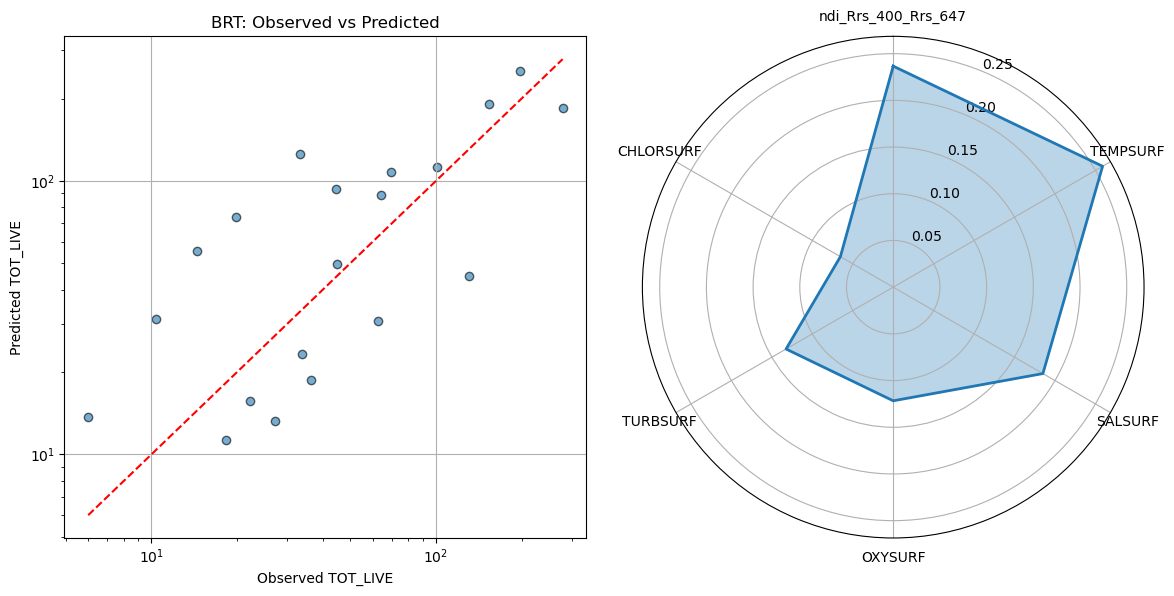

In [51]:
# Prepare data for STAR plot
importances = brt.feature_importances_
importances = importances / importances.sum()
labels = predictors
angles = np.linspace(0, 2 * np.pi, len(importances), endpoint=False)

# Close the loop for polar plot
angles = np.concatenate([angles, angles[:1]])
importances_plot = np.concatenate([importances, importances[:1]])

# We predicted log10(TOT_LIVE), let's convert it back to linear space
# it's a stylistic choice, but we can set our plot scales to log; that way our units are understandable
y_test_lin = 10 ** y_test
y_pred_lin = 10 ** y_pred

# Create side-by-side figure
fig = plt.figure(figsize=(12, 6))

# Scatter plot (left)
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(y_test_lin, y_pred_lin, alpha=0.6, edgecolor="k")
ax1.plot([y_test_lin.min(), y_test_lin.max()],
         [y_test_lin.min(), y_test_lin.max()],
         "r--")
ax1.set_xlabel("Observed TOT_LIVE")
ax1.set_ylabel("Predicted TOT_LIVE")
ax1.set_title("BRT: Observed vs Predicted")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(True)

# Polar plot (right)
ax2 = fig.add_subplot(1, 2, 2, polar=True)
ax2.plot(angles, importances_plot, linewidth=2)
ax2.fill(angles, importances_plot, alpha=0.3)
ax2.set_theta_direction(-1)
ax2.set_theta_offset(np.pi / 2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels)
#ax2.set_title("BRT Feature Importance", pad=25)

plt.tight_layout()
plt.show()



On the left, we have a scatter plot comparing the BRT’s predicted values to the observed values of our target. On the right, the STAR (polar) plot shows the relative importance of each predictor. In a BRT, a variable’s importance reflects how much it contributed to reducing prediction error across all the trees. Higher values mean the model “relied on” that variable more. These values are normalized to sum to 1, so you can see at a glance which predictors had the biggest influence on the model, even when interactions and nonlinear effects are present.

Turns out the PACE NDI was the second most influential factor in the model, behind surface temperature. I wouldn't hang your hat on predicting fish catch with this model, but we did seem to at least capture a directional trend, with a modest, but respectible statistical correlation. Again, keep in mind, we only had 97 points, so our test dataset only consists of 20 points. If you try running the same model above without the presence of PACE data, you'll notice that the relationship is not as strong, but also that it picks up ~150 additional observations becuase it didn't have to filter by co-occuring satellite data. 

## Now the science begins!

Overall, this tutorial illustrates a workflow that’s very common in satellite data work: matching spatially and temporally explicit observations to environmental data, exploring relationships, and trying out simple predictive models. The bigger takeaway isn’t the specific numbers or predictions, but rather the approach. We learned how to handle shapefiles and satellite matchups, extract relevant data, and start exploring how environmental and spectral variables relate to biological patterns. With more data and further tuning, these workflows could be extended to better understand habitat use, fishing hotspots, or other ecological questions. In short, we hope that the tools and concepts you practiced here provide a solid foundation for integrating remote sensing and fisheries science in your own work.